In [1]:
import matplotlib.pyplot as plt
import numpy as np

from superfv.initial_conditions import modified_shu_osher
from superfv import run_multiple_simulations


In [2]:
N = 1000
Nref = 10000

init_params = dict(ic=modified_shu_osher, bcx=("free", "free"), xlims=(-5, 5))
run_params = dict(t=5.0, allow_overshoot=True)

In [3]:
musclhancock = dict(p=1, use_MUSCL=True, MUSCL_limiter="moncen")
apriori = dict(use_ZS=True, lazy_primitive_mode="adaptive", adaptive_dt=True)
aposteriori = dict(use_MOOD=True, lazy_primitive_mode="full", MUSCL_limiter="moncen", positivity_guard=False)
aposteriori_1rev = dict(fallback_cascade="muscl", max_revs=1, **aposteriori)
aposteriori_2revs = dict(fallback_cascade="muscl0", max_revs=2, **aposteriori)
aposteriori_3revs = dict(fallback_cascade="muscl0", max_revs=3, **aposteriori)

configs = {
    "ref": musclhancock,
    "MUSCL-Hancock": musclhancock,
    "ZS3": dict(p=3, **apriori),
    "ZS7": dict(p=7, **apriori),
    "ZS3/no_SED": dict(p=3, use_SED=False, **apriori),
    "ZS7/no_SED": dict(p=7, use_SED=False, **apriori),
    "MM3/1rev/no_NAD": dict(p=3, use_NAD=False, use_SED=False, **aposteriori_1rev),
    "MM7/1rev/no_NAD": dict(p=7, use_NAD=False, use_SED=False, **aposteriori_1rev),
    "MM3/1rev/rtol_1e-1": dict(p=3, rtol=1e-1, **aposteriori_1rev),
    "MM7/1rev/rtol_1e-1": dict(p=7, rtol=1e-1, **aposteriori_1rev),
    "MM3/1rev/rtol_1e-3": dict(p=3, rtol=1e-3, **aposteriori_1rev),
    "MM7/1rev/rtol_1e-3": dict(p=7, rtol=1e-3, **aposteriori_1rev),
    "MM3/1rev/rtol_1e-5": dict(p=3, rtol=1e-5, **aposteriori_1rev),
    "MM7/1rev/rtol_1e-5": dict(p=7, rtol=1e-5, **aposteriori_1rev),
    "MM3/1rev/rtol_0": dict(p=3, rtol=0, **aposteriori_1rev),
    "MM7/1rev/rtol_0": dict(p=7, rtol=0, **aposteriori_1rev),
    "ZS3-RK4": dict(p=3, **apriori),
    "ZS7-RK4": dict(p=7, **apriori),
    "MM3-RK4/1rev/rtol_1e-1": dict(p=3, rtol=1e-1, **aposteriori_1rev),
    "MM7-RK4/1rev/rtol_1e-1": dict(p=7, rtol=1e-1, **aposteriori_1rev),
}

In [4]:
sims = {}


def postprocess(name, sim):
    sims[name] = sim


run_multiple_simulations(
    {
        name: (
            dict(nx=Nref if name == "ref" else N, **init_params, **config),
            dict(
                time_integrator=(
                    "rk4"
                    if "RK4" in name
                    else "ssprk3"
                    if "RK3" in name
                    else "muscl_hancock"
                    if config.get("use_MUSCL", False)
                    else "match_p_up_to_ssprk3"
                ),
                **run_params,
            ),
        )
        for name, config in configs.items()
    },
    "/scratch/gpfs/jp7427/out/modified-shu-osher/N_1000/",
    postprocess=postprocess,
)

Loaded existing output for simulation 'ref' from '/scratch/gpfs/jp7427/out/modified-shu-osher/N_1000/ref'.
Loaded existing output for simulation 'MUSCL-Hancock' from '/scratch/gpfs/jp7427/out/modified-shu-osher/N_1000/MUSCL-Hancock'.
Loaded existing output for simulation 'ZS3' from '/scratch/gpfs/jp7427/out/modified-shu-osher/N_1000/ZS3'.
Loaded existing output for simulation 'ZS7' from '/scratch/gpfs/jp7427/out/modified-shu-osher/N_1000/ZS7'.
Loaded existing output for simulation 'ZS3/no_SED' from '/scratch/gpfs/jp7427/out/modified-shu-osher/N_1000/ZS3/no_SED'.
Loaded existing output for simulation 'ZS7/no_SED' from '/scratch/gpfs/jp7427/out/modified-shu-osher/N_1000/ZS7/no_SED'.
Loaded existing output for simulation 'MM3/1rev/no_NAD' from '/scratch/gpfs/jp7427/out/modified-shu-osher/N_1000/MM3/1rev/no_NAD'.
Loaded existing output for simulation 'MM7/1rev/no_NAD' from '/scratch/gpfs/jp7427/out/modified-shu-osher/N_1000/MM7/1rev/no_NAD'.
Loaded existing output for simulation 'MM3/1rev/

-> Loaded snapshot at t=5.0000461014771265 from /scratch/gpfs/jp7427/out/modified-shu-osher/ref/output_000001.pkl.
-> Loaded snapshot at t=5.002504359323623 from /scratch/gpfs/jp7427/out/modified-shu-osher/N_1000/ZS3/output_000001.pkl.
-> Loaded snapshot at t=5.003401673085629 from /scratch/gpfs/jp7427/out/modified-shu-osher/N_1000/ZS7/output_000001.pkl.
-> Loaded snapshot at t=5.0030458636299455 from /scratch/gpfs/jp7427/out/modified-shu-osher/N_1000/MM3/1rev/no_NAD/output_000001.pkl.
-> Loaded snapshot at t=5.001353332277043 from /scratch/gpfs/jp7427/out/modified-shu-osher/N_1000/MM3/1rev/rtol_0/output_000001.pkl.
-> Loaded snapshot at t=5.00038359845661 from /scratch/gpfs/jp7427/out/modified-shu-osher/N_1000/MM7/1rev/no_NAD/output_000001.pkl.
-> Loaded snapshot at t=5.0042306131226875 from /scratch/gpfs/jp7427/out/modified-shu-osher/N_1000/MM7/1rev/rtol_0/output_000001.pkl.


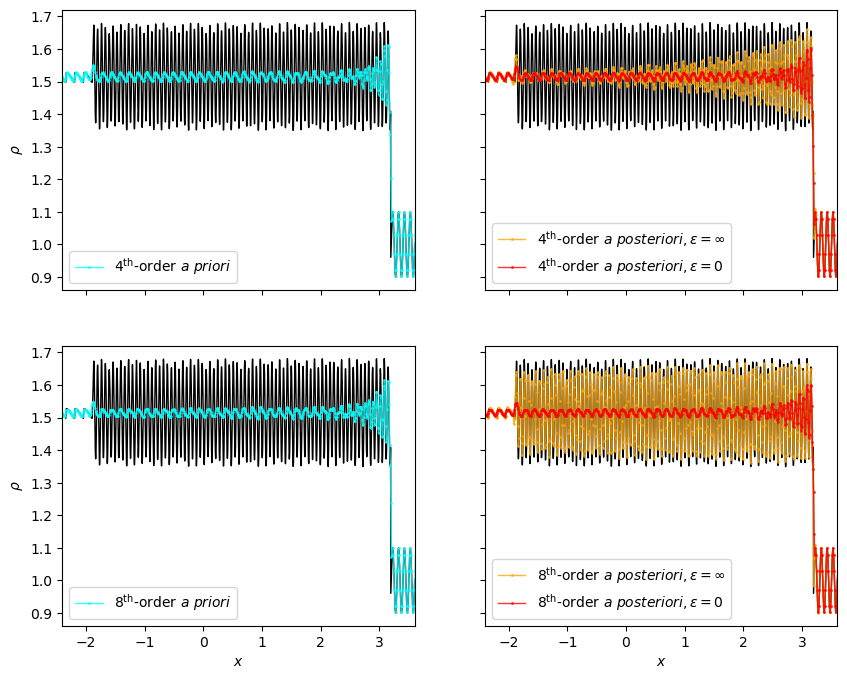

In [5]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10, 8))
axs[1, 0].set_xlabel(r"$x$")
axs[1, 1].set_xlabel(r"$x$")
axs[0, 0].set_ylabel(r"$\rho$")
axs[1, 0].set_ylabel(r"$\rho$")
axs[0, 0].set_xlim(-2.4, 3.6)

cmap1 = plt.get_cmap("GnBu")
cmap2 = plt.get_cmap("OrRd")


def plot(name, ax, v, style=dict()):
    _style = dict(
        label=name,
        linestyle="-" if name == "ref" else "-",
        linewidth=1,
        markersize=1,
        marker="none" if name == "ref" else "o",
        mfc="none",
        alpha=1 if name == "ref" else 0.8,
    )
    _style.update(style)

    sim = sims[name]
    idx = sim.params.variable_index_map
    snapshot = sim.snapshot_history[-1]
    x = sim.mesh.centers[0]

    if v == "theta":
        q = _style.pop("multivar_func")(idx, sim.mesh, snapshot.theta)
    elif v == "cascade":
        q = snapshot.cascade_idx[0]
    else:
        q = snapshot.w[idx(v)]

    ax.plot(x, q.squeeze(), **_style)


plot("ref", axs[0, 0], "rho", dict(label="_nolegend_", color="k"))
plot("ZS3", axs[0, 0], "rho", dict(label=r"$4^{\mathrm{th}}$-order $\mathit{a\ priori}$", color="cyan"))
# plot(
#     "ZS3/no_SED",
#     axs[0, 0],
#     "rho",
#     dict(label="LB4, no SED", color="royalblue", linestyle="dashdot"),
# )
# plot("MUSCL-Hancock", axs[0, 0], "rho", dict(color="grey"))

plot("ref", axs[1, 0], "rho", dict(label="_nolegend_", color="k"))
plot("ZS7", axs[1, 0], "rho", dict(label=r"$8^{\mathrm{th}}$-order $\mathit{a\ priori}$", color="cyan"))
# plot(
#     "ZS7/no_SED",
#     axs[1, 0],
#     "rho",
#     dict(label="LB8, no SED", color="royalblue", linestyle="dashdot"),
# )
# plot("MUSCL-Hancock", axs[1, 0], "rho", dict(label="_nolegend_", color="grey"))

plot("ref", axs[0, 1], "rho", dict(label="_nolegend_", color="k"))
# plot(
#     "MM3/1rev/no_NAD",
#     axs[0, 1],
#     "rho",
#     dict(label=r"MM4, $\epsilon=\infty$", color="gold"),
# )
plot(
    "MM3/1rev/no_NAD",
    axs[0, 1],
    "rho",
    dict(label=r"$4^{\mathrm{th}}$-order $\mathit{a\ posteriori}, \epsilon=\infty$", color="orange"),
)
plot(
    "MM3/1rev/rtol_0",
    axs[0, 1],
    "rho",
    dict(label=r"$4^{\mathrm{th}}$-order $\mathit{a\ posteriori}, \epsilon=0$", color="red"),
)
# plot("MUSCL-Hancock", axs[0, 1], "rho", dict(label="_nolegend_", color="grey"))

plot("ref", axs[1, 1], "rho", dict(label="_nolegend_", color="k"))
# plot(
#     "MM7/1rev/no_NAD",
#     axs[1, 1],
#     "rho",
#     dict(label=r"MM8, $\epsilon=\infty$", color="gold"),
# )
plot(
    "MM7/1rev/no_NAD",
    axs[1, 1],
    "rho",
    dict(label=r"$8^{\mathrm{th}}$-order $\mathit{a\ posteriori}, \epsilon=\infty$", color="orange"),
)
plot(
    "MM7/1rev/rtol_0",
    axs[1, 1],
    "rho",
    dict(label=r"$8^{\mathrm{th}}$-order $\mathit{a\ posteriori}, \epsilon=0$", color="red"),
)
# plot("MUSCL-Hancock", axs[1, 1], "rho", dict(label="_nolegend_", color="grey"))


axs[0, 0].legend()
axs[1, 0].legend()
axs[0, 1].legend()
axs[1, 1].legend()

In [6]:
fig.savefig("modified-shu-osher.pdf")

-> Loaded snapshot at t=5.001063341811329 from /scratch/gpfs/jp7427/out/modified-shu-osher/N_1000/MM7/1rev/rtol_1e-1/output_000001.pkl.


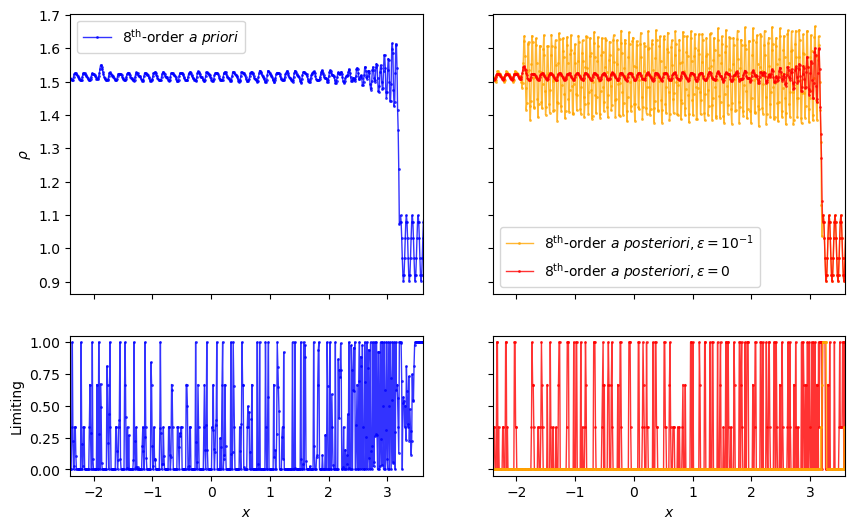

In [7]:
fig, axs = plt.subplots(
    2,
    2,
    sharex=True,
    sharey="row",
    figsize=(10, 6),
    gridspec_kw={"height_ratios": [2, 1]},
)
axs[1, 0].set_xlabel(r"$x$")
axs[1, 1].set_xlabel(r"$x$")
axs[0, 0].set_ylabel(r"$\rho$")
axs[1, 0].set_ylabel("Limiting")
axs[0, 0].set_xlim(-2.4, 3.6)

cmap1 = plt.get_cmap("GnBu")
cmap2 = plt.get_cmap("OrRd")


# plot("ref", axs[0, 0], "rho", dict(color="k"))
plot(
    "ZS7",
    axs[0, 0],
    "rho",
    dict(label=r"$8^{\mathrm{th}}$-order $\mathit{a\ priori}$", color="blue"),
)

plot(
    "ZS7",
    axs[1, 0],
    "theta",
    dict(
        label=r"$8^{\mathrm{th}}$-order $\mathit{a\ priori}$",
        color="blue",
        multivar_func=lambda idx, _, _theta: 1
        - np.minimum(np.minimum(_theta[idx("rho")], _theta[idx("vx")]), _theta[idx("P")]),
    ),
)

# plot("ref", axs[0, 1], "rho", dict(color="k"))
# plot(
#     "MM7/1rev/no_NAD",
#     axs[0, 1],
#     "rho",
#     dict(label=r"MM8, $\epsilon=\infty$", color=cmap2(0.25)),
# )
# plot(
#     "MM7/1rev/rtol_1e-1",
#     axs[0, 1],
#     "rho",
#     dict(label=r"MM8, $\epsilon=10^{-1}$", color=cmap2(0.5)),
# )
plot(
    "MM7/1rev/rtol_1e-1",
    axs[0, 1],
    "rho",
    dict(label=r"$8^{\mathrm{th}}$-order $\mathit{a\ posteriori}, \epsilon=10^{-1}$", color="orange"),
)
plot(
    "MM7/1rev/rtol_0",
    axs[0, 1],
    "rho",
    dict(label=r"$8^{\mathrm{th}}$-order $\mathit{a\ posteriori}, \epsilon=0$", color="red"),
)


plot(
    "MM7/1rev/rtol_0",
    axs[1, 1],
    "cascade",
    dict(label=r"$8^{\mathrm{th}}$-order $\mathit{a\ posteriori}, \epsilon=0$", color="red"),
)
plot(
    "MM7/1rev/rtol_1e-1",
    axs[1, 1],
    "cascade",
    dict(label=r"$8^{\mathrm{th}}$-order $\mathit{a\ posteriori}, \epsilon=10^{-1}$", color="orange"),
)

# plot(
#     "MM7/1rev/rtol_1e-1",
#     axs[1, 1],
#     "cascade",
#     dict(label=r"MM8, $\epsilon=10^{-1}$", color=cmap2(0.5)),
# )
# plot(
#     "MM7/1rev/no_NAD",
#     axs[1, 1],
#     "cascade",
#     dict(label=r"MM8, $\epsilon=\infty$", color=cmap2(0.25)),
# )

axs[0, 0].legend()
axs[0, 1].legend()

In [8]:
fig.savefig("modified-shu-osher-troubles.pdf")

-> Loaded snapshot at t=5.000100339651781 from /scratch/gpfs/jp7427/out/modified-shu-osher/N_1000/ZS3-RK4/output_000001.pkl.
-> Loaded snapshot at t=5.00284950555382 from /scratch/gpfs/jp7427/out/modified-shu-osher/N_1000/ZS7-RK4/output_000001.pkl.
-> Loaded snapshot at t=5.000890207499186 from /scratch/gpfs/jp7427/out/modified-shu-osher/N_1000/MM3/1rev/rtol_1e-1/output_000001.pkl.
-> Loaded snapshot at t=5.001805370400751 from /scratch/gpfs/jp7427/out/modified-shu-osher/N_1000/MM3-RK4/1rev/rtol_1e-1/output_000001.pkl.
-> Loaded snapshot at t=5.003573545663516 from /scratch/gpfs/jp7427/out/modified-shu-osher/N_1000/MM7-RK4/1rev/rtol_1e-1/output_000001.pkl.


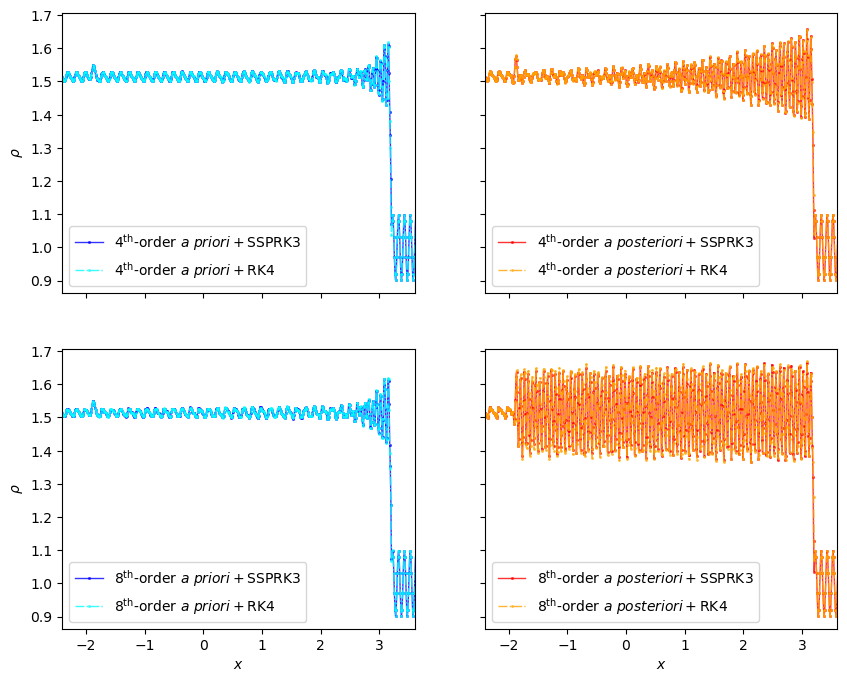

In [9]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10, 8))
axs[1, 0].set_xlabel(r"$x$")
axs[1, 1].set_xlabel(r"$x$")
axs[0, 0].set_ylabel(r"$\rho$")
axs[1, 0].set_ylabel(r"$\rho$")
axs[0, 0].set_xlim(-2.4, 3.6)

cmap1 = plt.get_cmap("GnBu")
cmap2 = plt.get_cmap("OrRd")

# plot("ref", axs[0, 0], "rho", dict(color="k"))
plot("ZS3", axs[0, 0], "rho", dict(label=r"$4^{\mathrm{th}}$-order $\mathit{a\ priori}+$SSPRK3", color="blue", marker="s"))
plot(
    "ZS3-RK4",
    axs[0, 0],
    "rho",
    dict(label=r"$4^{\mathrm{th}}$-order $\mathit{a\ priori}+$RK4", color="cyan", linestyle="dashdot"),
)

# plot("ref", axs[1, 0], "rho", dict(label="_nolegend_", color="k"))
plot("ZS7", axs[1, 0], "rho", dict(label=r"$8^{\mathrm{th}}$-order $\mathit{a\ priori}+$SSPRK3", color="blue", marker="s"))
plot(
    "ZS7-RK4",
    axs[1, 0],
    "rho",
    dict(label=r"$8^{\mathrm{th}}$-order $\mathit{a\ priori}+$RK4", color="cyan", linestyle="dashdot"),
)

# plot("ref", axs[0, 1], "rho", dict(label="_nolegend_", color="k"))
plot(
    "MM3/1rev/rtol_1e-1",
    axs[0, 1],
    "rho",
    dict(label=r"$4^{\mathrm{th}}$-order $\mathit{a\ posteriori}+$SSPRK3", color="red", marker="s"),
)
plot(
    "MM3-RK4/1rev/rtol_1e-1",
    axs[0, 1],
    "rho",
    dict(label=r"$4^{\mathrm{th}}$-order $\mathit{a\ posteriori}+$RK4", color="orange", linestyle="dashdot"),
)

# plot("ref", axs[1, 1], "rho", dict(label="_nolegend_", color="k"))
plot(
    "MM7/1rev/rtol_1e-1",
    axs[1, 1],
    "rho",
    dict(label=r"$8^{\mathrm{th}}$-order $\mathit{a\ posteriori}+$SSPRK3", color="red", marker="s"),
)
plot(
    "MM7-RK4/1rev/rtol_1e-1",
    axs[1, 1],
    "rho",
    dict(label=r"$8^{\mathrm{th}}$-order $\mathit{a\ posteriori}+$RK4", color="orange", linestyle="dashdot"),
)


axs[0, 0].legend()
axs[1, 0].legend()
axs[0, 1].legend()
axs[1, 1].legend()

In [10]:
fig.savefig("modified-shu-osher_RK3-vs-RK4.pdf")